# 2. Unconfined Aquifer Test - Vennebulten

### Import packages

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import timflow.transient as tft

plt.rcParams["figure.figsize"] = (5, 3)  # default figure size

### Introduction and Conceptual Model

In aquifer tests in unconfined aquifers, there is also the vertical component to flow to the well. The drawdown data shows the delayed water table response, a distinguishable S-shape in the log-log plot. In the early times of the drawdown, the drawdown behaves as a confined aquifer: when the aquifer releases the elastic storage. However, as pumping continues, the water table storage begins to be released, generating further drawdown and the S-shape.

This test conducted in Vennebulten, the Netherlands, is reported in Kruseman et al. (1970). The cross-section consists of a first layer up to 6 m depth of very fine and loamy sands, followed by coarse sands until 21 m deep.

The screen of the pumping well is placed between 10 and 21 meters depth, and pumping has taken place for 25 hours at a rate of 873 m3/d. The available drawdown data comes from two piezometers, a shallow one, screened at 3 m depth, and a deeper one, screened in the depths between 12 to 19 m. Both wells are located 90 m from the pumping well.

<img src="./figs/Vennebulten.png" style="width:400pt">

### Load data 

In [8]:
data1 = np.loadtxt("data/venne_shallow.txt", skiprows=1)
ts = data1[:, 0] / 60 / 24  # convert min to days
hs = data1[:, 1]

data2 = np.loadtxt("data/venne_deep.txt", skiprows=1)
td = data2[:, 0] / 60 / 24  # convert min to days
hd = data2[:, 1]

### Parameters and model

In [10]:
b = -21  # aquifer thickness, m
r = 90  # distance from observation wells to pumping well, m
Q = 873  # constant discharge, m^3/d
k = 12 * [0.5] + 15 * [150]
z = np.hstack((np.arange(0, -6, -0.5), np.arange(-6, -21.1, -1)))
Ss = [0.2] + 26 * [1e-4]
kzoverkh = 0.1

In [11]:
ml = tft.Model3D(
    kaq=k,
    z=z,
    Saq=Ss,
    kzoverkh=kzoverkh,
    topboundary='conf',
    phreatictop=True,
    tmin=1e-4,
    tmax=1.1,
)
w = tft.Well(ml, xw=0, yw=0, rw=0.1, tsandQ=[(0, Q)], layers=range(10, 21))
wobs = tft.Well(ml, xw=90, yw=0, rw=0.1, tsandQ=[(0, 0)], layers=range(18, 27))
ml.solve()

self.neq  20
solution complete


### Estimate aquifer parameters

In [13]:
cal = tft.Calibrate(ml)

cal.set_parameter(name="Saq", initial=1e-4, layers=list(range(1, 12)), pmin=1e-6, pmax=1e-2)
cal.set_parameter(name="kaq", initial=150, layers=list(range(0, 12)), pmin=0.05, pmax=1)

cal.set_parameter(name="Saq", initial=1e-4,   layers=list(range(12, 27)),   pmin=1e-6,   pmax=1e-2,)
cal.set_parameter(name="kaq", initial=150, layers=list(range(12, 27)), pmin=100, pmax=200)

cal.series(name="shallow_obs", x=r, y=0, t=ts, h=hs, layer=5)
cal.seriesinwell(name="wobs", element=wobs, t=td, h=hd)

cal.fit(report=True)

.................................................
Fit succeeded.
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 46
    # data points      = 48
    # variables        = 4
    chi-square         = 0.00321402
    reduced chi-square = 7.3046e-05
    Akaike info crit   = -453.348749
    Bayesian info crit = -445.863945
[[Variables]]
    Saq_1_11:   3.4342e-04 +/- 1.0780e-04 (31.39%) (init = 0.0001)
    kaq_0_11:   0.19717205 +/- 0.08047516 (40.81%) (init = 1)
    Saq_12_26:  2.8535e-05 +/- 3.1528e-06 (11.05%) (init = 0.0001)
    kaq_12_26:  100.306872 +/- 10.8778262 (10.84%) (init = 150)
[[Correlations]] (unreported correlations are < 0.100)
    C(kaq_0_11, kaq_12_26)  = -0.9779
    C(Saq_1_11, kaq_12_26)  = -0.9372
    C(Saq_1_11, kaq_0_11)   = +0.9191
    C(Saq_1_11, Saq_12_26)  = -0.3984
    C(kaq_0_11, Saq_12_26)  = -0.3178
    C(Saq_12_26, kaq_12_26) = +0.2546


In [14]:
display(cal.parameters.loc[:, ["optimal"]])
print(f"RMSE: {cal.rmse():.3f} m")

,optimal
Saq_1_11,0.000343
kaq_0_11,0.197172
Saq_12_26,0.000029
kaq_12_26,100.306872


RMSE: 0.008 m


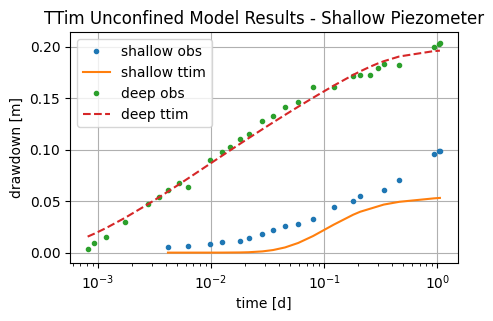

In [15]:
hs_1 = ml.head(r, 0, ts, layers=3)
hd_1 = wobs.headinside(td)

plt.semilogx(ts, -hs, ".", label="shallow obs")
plt.semilogx(ts, -hs_1[0], label="shallow ttim")
plt.semilogx(td, -hd, ".", label="deep obs")
plt.semilogx(td, -hd_1[0], '--', label="deep ttim")
plt.xlabel("time [d]")
plt.ylabel("drawdown [m]")
plt.title("TTim Unconfined Model Results - Shallow Piezometer")
plt.legend()
plt.grid()

### Comparison of results
The performance of `timflow` is compared with a model performed with MLU (Hemker & Post, 2014). The schematization of the MLU model differs considerably. The model consists of three layers: a very thin fine-grained upper aquifer layer with horizontal flow and two deeper sublayers with a thickness of 1 and 10 meters. In total, four parameters were estimated (Ss0, c2, Ss2, k2), while fixed values were chosen for the remaining ones. 

The RMSE of MLU is smaller than that of MLU. 

In [17]:
t = pd.DataFrame(
    columns=[ "Ss0 [1/m]", "k0 [m/d]", "c1 [d]", "Ss1 [1/m]", "k1 [m/d]", "c2 [d]", "Ss2 [1/m]", "k2 [m/d]", "RMSE [m]"],
    index=["timflow", "MLU"],
)

t.loc["timflow"] = [cal.parameters["optimal"].values[0], cal.parameters["optimal"].values[1], "-",  cal.parameters["optimal"].values[2], cal.parameters["optimal"].values[3], "-", "-", "-", cal.rmse()]
t.loc["MLU"] = [0.38, 1, 100, 1e-6, 50, 209, 0.00558, 165.9, 0.0005]

t_formatted = t.style.format(
    {"Ss0 [1/m]" : "{:.2e}", 
     "k0 [m/d]" : "{:.2f}", 
     "c1 [d]" : lambda x: "-" if x == "-" else f"{float(x):.0f}",
     "Ss1 [1/m]" : "{:.2e}", 
     "k1 [m/d]" : "{:.2f}", 
     "c2 [d]" : lambda x: "-" if x == "-" else f"{float(x):.0f}", 
     "Ss2 [1/m]" : lambda x: "-" if x == "-" else f"{float(x):.2e}", 
     "k2 [m/d]" : lambda x: "-" if x == "-" else f"{float(x):.2f}", 
     "RMSE [m]" : "{:.4f}",
    }
)
t_formatted

,Ss0 [1/m],k0 [m/d],c1 [d],Ss1 [1/m],k1 [m/d],c2 [d],Ss2 [1/m],k2 [m/d],RMSE [m]
timflow,3.43e-04,0.20,-,2.85e-05,100.31,-,-,-,0.0082
MLU,3.80e-01,1.00,100,1.00e-06,50.00,209,5.58e-03,165.90,0.0005


## References
* Hemker, K. en Post V. (2014) MLU for Windows: well flow modeling in multilayer aquifer systems; MLU User's guide. https://eur03.safelinks.protection.outlook.com/?url=https%3A%2F%2Fmicrofem.com%2Fdownload%2Fmlu-user.pdf&data=05%7C02%7CMark.Bakker%40tudelft.nl%7Cad7f16364d2d4fd55dbf08de73832eaa%7C096e524d692940308cd38ab42de0887b%7C0%7C0%7C639075204580287861%7CUnknown%7CTWFpbGZsb3d8eyJFbXB0eU1hcGkiOnRydWUsIlYiOiIwLjAuMDAwMCIsIlAiOiJXaW4zMiIsIkFOIjoiTWFpbCIsIldUIjoyfQ%3D%3D%7C0%7C%7C%7C&sdata=OBoe8seXZUfoat89Dfr4g6lF%2Bn1FdtXqtp%2F18BMXCn0%3D&reserved=0
* Kruseman, G.P., De Ridder, N.A., Verweij, J.M., 1970. Analysis and evaluationof pumping test data. volume 11. International institute for land reclamation and improvement The Netherlands.
* Neuman, S.P., Witherspoon, P.A., 1969. Applicability of current theories of flow in leaky aquifers. Water Resources Research 5, 817–829.